# Heart failure: verkennend dataonderzoek
Dit notebook onderzoekt de kwaliteit en verdeling van alle 15 kolommen. Het CSV-bestand blijft ongewijzigd. We onderzoeken de geregistreerde uitkomst **HeartDisease**; de gegevens tonen niet vanzelf toekomstig risico.

**Werkwijze:** kies de kernel `.venv` en voer de cellen van boven naar beneden uit (Run All). Met Shift + Enter voer je één cel uit. De aantallen in tabellen en het eindoverzicht worden telkens opnieuw berekend.

## Inhoud
1. Inlezen en overzicht van alle kolommen
2. Dubbele rijen en identificerende gegevens
3. Numerieke metingen: Age, RestingBP, Cholesterol, MaxHR en Oldpeak
4. Categorieën: Sex, ChestPainType, FastingBS, RestingECG, ExerciseAngina, ST_Slope en HeartDisease
5. Overzicht van aandachtspunten en vervolgstappen

Een afwijkende waarde is een **signaal voor onderzoek**, geen automatische reden om een rij te verwijderen. Onder elke kolom staat hoe je de uitkomst interpreteert.

## 1. Inlezen en overzicht
`pandas` verwerkt tabellen; `matplotlib` maakt grafieken. Identificerende kolommen lezen we als tekst, zodat eventuele voorloopnullen behouden blijven. Het pad werkt vanuit de map van dit notebook of vanuit de bovenliggende projectmappen.

In [43]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

mogelijke_paden = [
    Path('../data/Heart faillure prediction data.csv'),
    Path('heart-failure/data/Heart faillure prediction data.csv'),
    Path('data/Heart faillure prediction data.csv'),
]
bestand = next((pad for pad in mogelijke_paden if pad.is_file()), None)
if bestand is None:
    raise FileNotFoundError('CSV niet gevonden. Open dit notebook vanuit de map heart-failure/code.')

# Lees de CSV-data in
data = pd.read_csv(bestand, dtype={ 
    'CaseNumber': 'string', 'LastName': 'string', 'PostCode': 'string'
})

# Geleerd van de cursus.
x = data.iloc[:, :-1].values # Alle kolommen behalve de laatste (HeartDisease) Dit is de input (features)
y = data.iloc[:, -1].values # Alleen de laatste kolom (HeartDisease) Dit is de output (target)

print(f'Dataset: {data.shape[0]} rijen en {data.shape[1]} kolommen.') # Toon de afmetingen van het dataset
display(data[['Age', 'Sex', 'Cholesterol', 'HeartDisease']].head()) # Toon de eerste 5 rijen van de geselecteerde kolommen

Dataset: 918 rijen en 15 kolommen.


,Age,Sex,Cholesterol,HeartDisease
0,40.0,M,289,0
1,49.0,F,180,1
2,37.0,M,283,0
3,48.0,F,214,1
4,54.0,M,195,0


In [44]:
print(x) # Toon de input (features)
print(y) # Toon de output (target)

[['431-06-4243' 'Richard' '99847' ... 'N' 0.0 'Up']
 ['415-39-7809' 'Sheppard' '64192' ... 'N' 1.0 'Flat']
 ['517-18-4618' 'Howard' '29132' ... 'N' 0.0 'Up']
 ...
 ['795-34-3503' 'Franklin' '57897' ... 'Y' 1.2 'Flat']
 ['076-03-0800' 'Herrera' '65198' ... 'N' 0.0 'Flat']
 ['505-97-3265' 'Wheeler' '22958' ... 'N' 0.0 'Up']]
<StringArray>
['0', '1', '0', '1', '0', '0', '0', '0', '1', '0',
 ...
 '1', '1', '0', '1', '1', '1', '1', '1', '1', '0']
Length: 918, dtype: str


### Welke test hoort bij welke kolom?
Alle kolommen krijgen een controle op ontbrekende waarden en datatype. Bij metingen bekijken we statistieken, nulwaarden, negatieve waarden en een histogram. Bij categorieën tellen we codes en vergelijken we deze met de opdracht. Bij identificerende gegevens zijn een gemiddelde of histogram niet zinvol.

`isna()` herkent ontbrekende waarden. De extra tekstcontrole herkent ook velden die alleen uit spaties bestaan. Nullen worden apart onderzocht. Een numeriek datatype betekent niet automatisch dat een kolom een meting is: FastingBS en RestingECG bevatten categoriecodes.

In [45]:
metingen = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
toegestane_codes = {
    'Sex': ['M', 'F'],
    'ChestPainType': ['TA', 'ATA', 'NAP', 'ASY'],
    'FastingBS': ['0', '1'],
    'RestingECG': ['0', '1', '2'],
    'ExerciseAngina': ['Y', 'N'],
    'ST_Slope': ['Up', 'Flat', 'Down'],
    'HeartDisease': ['0', '1'],
}

tekst = data.astype('string')
ontbreekt = data.isna() | tekst.apply(lambda kolom: kolom.str.strip().eq('').fillna(False))
overzicht = pd.DataFrame({
    'Datatype': data.dtypes.astype(str),
    'Ontbrekend': ontbreekt.sum(),
    'Unieke waarden': data.nunique(dropna=True),
})
display(overzicht)

# Hier verzamelen we controles voor het eindoverzicht.
aandachtspunten = []
for kolom in data.columns:
    aandachtspunten.append({
        'Kolom': kolom, 'Controle': 'Ontbrekende of lege waarden',
        'Aantal': int(ontbreekt[kolom].sum()),
        'Vervolg': 'Onderzoek of herstel via de bron mogelijk is.'
    })

,Datatype,Ontbrekend,Unieke waarden
CaseNumber,string,0,918
LastName,string,0,481
PostCode,string,0,917
Age,float64,3,50
Sex,str,0,3
ChestPainType,str,0,4
RestingBP,int64,0,69
Cholesterol,int64,0,222
FastingBS,int64,0,2
RestingECG,int64,0,3


## 2. Dubbele en identificerende gegevens
### 2.1 Dubbele rijen en casenummers
`duplicated().sum()` telt herhalingen na de eerste vermelding. We onderzoeken zowel identieke rijen als herhaalde, ingevulde casenummers. Verschillende casenummers bewijzen op zichzelf niet dat het verschillende personen zijn.

In [46]:
dubbele_rijen = int(data.duplicated().sum())
herhaalde_cases = int(data.loc[~ontbreekt['CaseNumber'], 'CaseNumber'].duplicated().sum())
print('Volledig dubbele rijen:', dubbele_rijen)
print('Herhaalde ingevulde casenummers:', herhaalde_cases)

for kolom, controle, aantal in [
    ('Alle kolommen', 'Volledig dubbele rijen', dubbele_rijen),
    ('CaseNumber', 'Herhaalde casenummers', herhaalde_cases),
]:
    aandachtspunten.append({'Kolom': kolom, 'Controle': controle, 'Aantal': aantal,
                           'Vervolg': 'Vergelijk de registraties voordat je iets verwijdert.'})

Volledig dubbele rijen: 0
Herhaalde ingevulde casenummers: 0


### 2.2 CaseNumber, LastName en PostCode
Ontbrekende waarden staan in het overzicht. Hier controleren we overtollige spaties en het postcodeformaat. De opdracht beschrijft PostCode als vier cijfers; afwijkingen kunnen ook betekenen dat de beschrijving niet bij deze dataset past.

Een achternaam hoeft niet uniek te zijn. We leggen daarom geen regel op dat namen uniek moeten zijn of uitsluitend letters moeten bevatten. Voor CaseNumber geeft de opdracht geen vast formaat. Deze identificerende gegevens gebruiken we niet automatisch als modelkenmerken; voor PostCode moet het nut en de mogelijke vertekening eerst worden onderbouwd.

In [47]:
for kolom in ['CaseNumber', 'LastName', 'PostCode']:
    waarden = data[kolom].astype('string')
    spaties = waarden.ne(waarden.str.strip()).fillna(False)
    print(f'{kolom}: {int(spaties.sum())} waarden met spaties aan begin/eind.')
    aandachtspunten.append({'Kolom': kolom, 'Controle': 'Spaties aan begin/eind',
        'Aantal': int(spaties.sum()), 'Vervolg': 'Controleer en documenteer eventuele normalisatie.'})

postcode = data['PostCode'].astype('string')
afwijkende_postcode = ~ontbreekt['PostCode'] & ~postcode.str.fullmatch(r'[0-9]{4}').fillna(False)
print('Postcodes die afwijken van de vier cijfers uit de opdracht:', int(afwijkende_postcode.sum()))
print('Verdeling van de lengte van ingevulde postcodes:')
display(postcode[~ontbreekt['PostCode']].str.len().value_counts().sort_index().rename('Aantal'))
aandachtspunten.append({'Kolom': 'PostCode', 'Controle': 'Afwijkend van vier cijfers',
    'Aantal': int(afwijkende_postcode.sum()),
    'Vervolg': 'Controleer of de formaatbeschrijving van de opdracht bij de bron past; niet afkappen.'})

CaseNumber: 0 waarden met spaties aan begin/eind.
LastName: 0 waarden met spaties aan begin/eind.
PostCode: 0 waarden met spaties aan begin/eind.
Postcodes die afwijken van de vier cijfers uit de opdracht: 918
Verdeling van de lengte van ingevulde postcodes:


PostCode
5    918
Name: Aantal, dtype: Int64

## 3. Numerieke metingen
Voor elke meting doen we dezelfde beschrijvende controles. De betekenis van een nul of negatief getal verschilt per kolom.

- `count`: aantal beschikbare numerieke waarden; `mean`: gemiddelde; `std`: standaardafwijking (spreiding).
- `min` en `max`: kleinste en grootste waarde.
- `25%`, `50%` en `75%`: kwartielen; `50%` is de mediaan. Tussen 25% en 75% ligt de middelste helft van de waarden.
- `value_counts()`: meest voorkomende exacte waarden.
- Het histogram laat aantallen per interval zien. Het gaat steeds om **alle patiënten**, niet alleen patiënten met een hartaandoening.

De functie hieronder bundelt de herhaalde code. `onderzoek_meting('Age')` voert die code uit voor Age. De oorspronkelijke kolom wordt niet veranderd. Niet-numerieke invoer wordt apart geteld; de statistieken gebruiken alleen waarden die als getal leesbaar zijn.

In [48]:
def onderzoek_meting(kolom, eenheid, nul_negatief_verdacht=True):
    waarden = pd.to_numeric(data[kolom], errors='coerce')
    niet_numeriek = ~ontbreekt[kolom] & waarden.isna()
    print(kolom)
    display(waarden.describe().to_frame('Waarde'))
    controle = pd.Series({
        'Ontbrekend': int(ontbreekt[kolom].sum()),
        'Niet als getal leesbaar': int(niet_numeriek.sum()),
        'Nulwaarden': int(waarden.eq(0).sum()),
        'Negatieve waarden': int(waarden.lt(0).sum()),
    }, name='Aantal')
    display(controle.to_frame())
    print('Vijf meest voorkomende exacte waarden:')
    display(waarden.value_counts().head(5).rename('Aantal').to_frame())
    if waarden.lt(0).any():
        print('Negatieve waarden (links staat de rij-index):')
        display(data.loc[waarden.lt(0), [kolom]])
    if waarden.notna().any():
        waarden.plot.hist(bins=10, edgecolor='black', figsize=(7, 3))
        plt.title(f'Verdeling van {kolom}')
        plt.xlabel(eenheid)
        plt.ylabel('Aantal patiënten')
        plt.tight_layout()
        plt.show()
    aandachtspunten.append({'Kolom': kolom, 'Controle': 'Niet-numerieke invoer',
        'Aantal': int(niet_numeriek.sum()), 'Vervolg': 'Controleer de oorspronkelijke registratie.'})
    if nul_negatief_verdacht:
        for label, masker in [('Nulwaarden', waarden.eq(0)), ('Negatieve waarden', waarden.lt(0))]:
            aandachtspunten.append({'Kolom': kolom, 'Controle': label,
                'Aantal': int(masker.sum()), 'Vervolg': 'Betekenis bij de bron controleren; niet automatisch corrigeren.'})

### 3.1 Age

Age


,Waarde
count,915.000000
mean,53.512568
std,9.448039
min,28.000000
25%,47.000000
50%,54.000000
75%,60.000000
max,77.000000


,Aantal
Ontbrekend,3
Niet als getal leesbaar,0
Nulwaarden,0
Negatieve waarden,0


Vijf meest voorkomende exacte waarden:


,Aantal
Age,
54.0,51
58.0,42
55.0,41
56.0,38
57.0,38


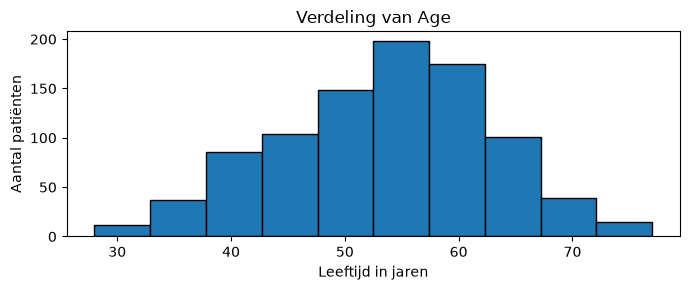

In [49]:
onderzoek_meting('Age', 'Leeftijd in jaren', nul_negatief_verdacht=True)

**Interpretatie en eerdere bevindingen**

De eerdere bevindingen waren een leeftijdsbereik van 28 tot 77 jaar en een mediaan van 54 jaar. De uitvoer hierboven geeft de actuele aantallen en statistieken. De frequentietabel controleert de eerdere bevinding dat 54 jaar het vaakst voorkomt. Een nul of negatieve leeftijd vraagt om onderzoek; leeftijd is niet op zichzelf bewijs voor een hartaandoening.

### 3.2 RestingBP

RestingBP


,Waarde
count,918.000000
mean,131.882353
std,21.881591
min,-126.000000
25%,120.000000
50%,130.000000
75%,140.000000
max,200.000000


,Aantal
Ontbrekend,0
Niet als getal leesbaar,0
Nulwaarden,1
Negatieve waarden,2


Vijf meest voorkomende exacte waarden:


,Aantal
RestingBP,
120,132
130,118
140,107
110,57
150,55


Negatieve waarden (links staat de rij-index):


,RestingBP
659,-126
895,-110


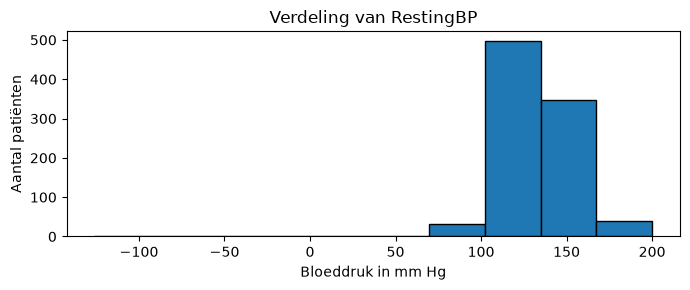

In [50]:
onderzoek_meting('RestingBP', 'Bloeddruk in mm Hg', nul_negatief_verdacht=True)

**Interpretatie en eerdere bevindingen**

De eerdere controle vond twee negatieve waarden (-126 en -110) en één nulwaarde. De tabel toont de actuele telling en de negatieve registraties. Uit een nulwaarde kunnen we niet afleiden dat een patiënt overleden is. Negatieve waarden worden niet zonder broncontrole positief gemaakt.

### 3.3 Cholesterol

Cholesterol


,Waarde
count,918.000000
mean,198.799564
std,109.384145
min,0.000000
25%,173.250000
50%,223.000000
75%,267.000000
max,603.000000


,Aantal
Ontbrekend,0
Niet als getal leesbaar,0
Nulwaarden,172
Negatieve waarden,0


Vijf meest voorkomende exacte waarden:


,Aantal
Cholesterol,
0,172
254,11
223,10
220,10
211,9


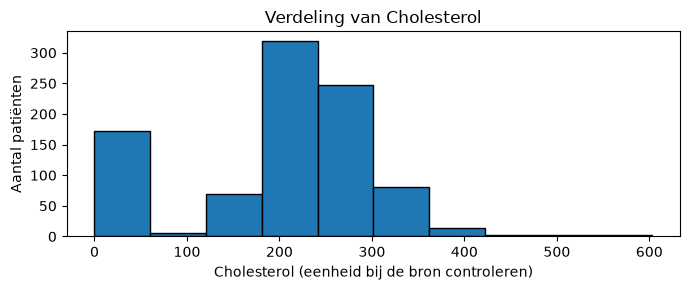

In [51]:
onderzoek_meting('Cholesterol', 'Cholesterol (eenheid bij de bron controleren)', nul_negatief_verdacht=True)

**Interpretatie en eerdere bevindingen**

De eerdere controle vond 172 nullen. Onderzoek of nul voor een ontbrekende meting staat. Als dat zo is, drukken de nullen het berekende gemiddelde. De eenheid staat in de opdracht als mm/dl; bevestig de bedoelde eenheid bij de bron voordat je grenswaarden toepast. Een hoge waarde wordt niet alleen wegens haar hoogte verwijderd.

### 3.4 MaxHR

MaxHR


,Waarde
count,918.000000
mean,136.809368
std,25.460334
min,60.000000
25%,120.000000
50%,138.000000
75%,156.000000
max,202.000000


,Aantal
Ontbrekend,0
Niet als getal leesbaar,0
Nulwaarden,0
Negatieve waarden,0


Vijf meest voorkomende exacte waarden:


,Aantal
MaxHR,
150,43
140,41
120,36
130,33
160,25


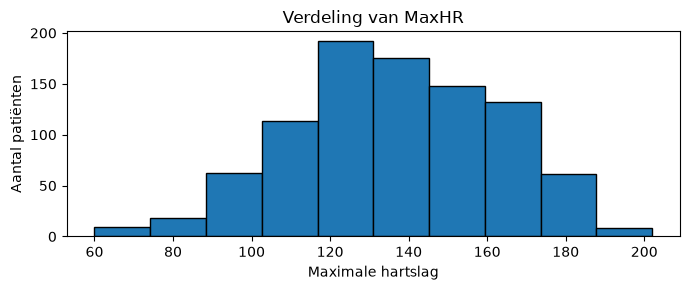

In [52]:
onderzoek_meting('MaxHR', 'Maximale hartslag', nul_negatief_verdacht=True)

**Interpretatie en eerdere bevindingen**

De opdracht beschrijft een bereik van 60 tot en met 202. De extra controle hieronder toetst dat beschreven bereik; dit is geen zelfstandig medisch criterium.

In [53]:
hartslag = pd.to_numeric(data['MaxHR'], errors='coerce')
buiten_bereik = hartslag.notna() & ~hartslag.between(60, 202)
print('MaxHR buiten het beschreven bereik 60 t/m 202:', int(buiten_bereik.sum()))
aandachtspunten.append({'Kolom': 'MaxHR', 'Controle': 'Buiten bereik uit opdracht (60–202)',
    'Aantal': int(buiten_bereik.sum()), 'Vervolg': 'Controleer bron en attribuutbeschrijving.'})

MaxHR buiten het beschreven bereik 60 t/m 202: 0


### 3.5 Oldpeak

Oldpeak


,Waarde
count,918.000000
mean,0.887364
std,1.066570
min,-2.600000
25%,0.000000
50%,0.600000
75%,1.500000
max,6.200000


,Aantal
Ontbrekend,0
Niet als getal leesbaar,0
Nulwaarden,368
Negatieve waarden,13


Vijf meest voorkomende exacte waarden:


,Aantal
Oldpeak,
0.0,368
1.0,86
2.0,76
1.5,53
3.0,28


Negatieve waarden (links staat de rij-index):


,Oldpeak
321,-0.9
324,-2.6
325,-1.5
326,-0.1
331,-1.0
332,-1.1
334,-0.7
335,-0.8
352,-1.0
407,-0.5


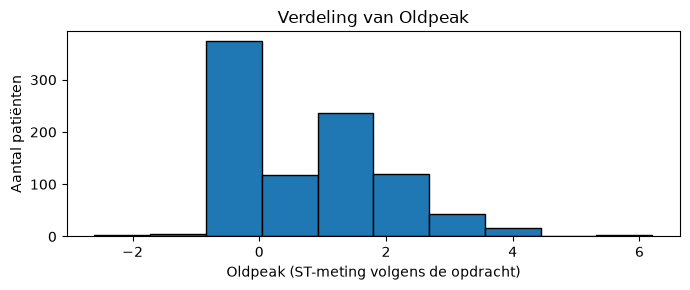

In [54]:
onderzoek_meting('Oldpeak', 'Oldpeak (ST-meting volgens de opdracht)', nul_negatief_verdacht=False)

**Interpretatie en eerdere bevindingen**

Nulwaarden en negatieve waarden worden geteld, maar hier niet automatisch als fout gemarkeerd. De betekenis en geldige grenzen hangen af van de meetdefinitie. Onderzoek opvallende waarden bij de bron voordat je ze corrigeert. Een negatieve Oldpeak heeft niet automatisch dezelfde betekenis als een negatieve RestingBP.

## 4. Categorische kolommen
Bij categorieën zijn aantallen en percentages zinvol. Een gemiddelde of controle op negatieve metingen past hier niet. De toegestane codes omvatten bij FastingBS, RestingECG en HeartDisease ook de code 0: die is dus niet automatisch een ontbrekende waarde.

We vergelijken de opgeslagen codes exact met de opdracht. Spaties, afwijkende hoofdletters en onbekende codes blijven zo zichtbaar. De vergelijking als tekst verandert de oorspronkelijke data niet. De percentages gebruiken alle rijen, ook eventuele ontbrekende waarden.

In [55]:
def onderzoek_categorie(kolom):
    waarden = data[kolom].astype('string')
    telling = waarden.value_counts(dropna=False)
    display(pd.DataFrame({
        'Aantal': telling,
        'Percentage van alle rijen': (telling / len(data) * 100).round(1),
    }))
    afwijkend = ~ontbreekt[kolom] & ~waarden.isin(toegestane_codes[kolom])
    print('Codes volgens de opdracht:', ', '.join(toegestane_codes[kolom]))
    print('Aantal niet-beschreven codes:', int(afwijkend.sum()))
    if afwijkend.any():
        display(waarden[afwijkend].value_counts().rename('Aantal').to_frame())
    aandachtspunten.append({'Kolom': kolom, 'Controle': 'Niet-beschreven categoriecode',
        'Aantal': int(afwijkend.sum()), 'Vervolg': 'Betekenis verifiëren voordat je codes omzet.'})

### 4.1 Sex

In [56]:
onderzoek_categorie('Sex')

,Aantal,Percentage van alle rijen
Sex,,
M,723,78.8
F,193,21.0
X,2,0.2


Codes volgens de opdracht: M, F
Aantal niet-beschreven codes: 2


,Aantal
Sex,
X,2


**Interpretatie**

Eerder werden M, F en twee keer X gevonden. X is niet beschreven in de opdracht, maar daarmee niet automatisch fout. De groepen zijn ongelijk vertegenwoordigd. De vraag of die verhouding moet worden overgenomen bij het trainen blijft onderdeel van de modelkeuzes: onderzoek eerst de beoogde populatie en beoordeel later prestaties per groep. Pas de verhouding niet willekeurig aan. Twee X-registraties zijn onvoldoende voor een betrouwbare afzonderlijke prestatiebeoordeling.

### 4.2 ChestPainType

In [57]:
onderzoek_categorie('ChestPainType')

,Aantal,Percentage van alle rijen
ChestPainType,,
ASY,496,54.0
NAP,203,22.1
ATA,173,18.8
TA,46,5.0


Codes volgens de opdracht: TA, ATA, NAP, ASY
Aantal niet-beschreven codes: 0


**Interpretatie**

Vergelijk de aantallen tussen de vier codes. De frequentie van een type pijn vertelt nog niet welk aandeel van die groep een hartaandoening heeft.

### 4.3 FastingBS

In [58]:
onderzoek_categorie('FastingBS')

,Aantal,Percentage van alle rijen
FastingBS,,
0,704,76.7
1,214,23.3


Codes volgens de opdracht: 0, 1
Aantal niet-beschreven codes: 0


**Interpretatie**

De codes 0 en 1 geven aan of de in de opdracht beschreven bloedsuikerdrempel is overschreden. Code 0 is een geldige categorie, geen ontbrekende meting.

### 4.4 RestingECG

In [59]:
onderzoek_categorie('RestingECG')

,Aantal,Percentage van alle rijen
RestingECG,,
0,552,60.1
2,188,20.5
1,178,19.4


Codes volgens de opdracht: 0, 1, 2
Aantal niet-beschreven codes: 0


**Interpretatie**

De codes 0, 1 en 2 zijn categorieën (Normal, ST en LVH volgens de opdracht). Ze vormen geen schaal waarop bijvoorbeeld 2 tweemaal zoveel betekent als 1.

### 4.5 ExerciseAngina

In [60]:
onderzoek_categorie('ExerciseAngina')

,Aantal,Percentage van alle rijen
ExerciseAngina,,
N,547,59.6
Y,371,40.4


Codes volgens de opdracht: Y, N
Aantal niet-beschreven codes: 0


**Interpretatie**

Y en N zijn de beschreven codes. Vergelijk aantallen en let op eventuele andere schrijfwijzen.

### 4.6 ST_Slope

In [61]:
onderzoek_categorie('ST_Slope')

,Aantal,Percentage van alle rijen
ST_Slope,,
Flat,460,50.1
Up,395,43.0
Down,63,6.9


Codes volgens de opdracht: Up, Flat, Down
Aantal niet-beschreven codes: 0


**Interpretatie**

Up, Flat en Down zijn de beschreven codes. Vergelijk hun aantallen; zet ze niet zonder onderbouwing om naar een numerieke afstandsschaal.

### 4.7 HeartDisease

In [62]:
onderzoek_categorie('HeartDisease')

,Aantal,Percentage van alle rijen
HeartDisease,,
1,501,54.6
0,410,44.7
yes,7,0.8


Codes volgens de opdracht: 0, 1
Aantal niet-beschreven codes: 7


,Aantal
HeartDisease,
yes,7


**Interpretatie**

Eerder werden 410 keer 0, 501 keer 1 en 7 keer yes gevonden. Dit is inconsistente codering. Dat yes gelijkstaat aan 1 is nog een aanname die bij de bron of docent moet worden bevestigd. Voeg deze groepen nog niet samen. Deze kolom is later de te voorspellen uitkomst, niet een invoerkenmerk.

## 5. Samenvatting en vervolgstappen
### 5.1 Automatisch overzicht van aandachtspunten
Deze tabel bundelt de controles met een resultaat groter dan nul. Aantallen komen rechtstreeks uit de eerdere code. Ze zijn **niet optelbaar tot een aantal patiënten**: dezelfde rij kan bij meerdere controles meetellen. De afwezigheid van een signaal bewijst niet dat een kolom foutloos is.

Voer Run All uit om het hele overzicht te vernieuwen. Als je tussentijds alleen een onderzoekscel opnieuw uitvoert, houdt de tabel voor iedere controle het laatste resultaat aan.

In [63]:
controles = pd.DataFrame(aandachtspunten).drop_duplicates(
    subset=['Kolom', 'Controle'], keep='last'
)
display(controles.loc[controles['Aantal'] > 0].reset_index(drop=True))
print('Dubbele rijen:', dubbele_rijen)
print('Herhaalde casenummers:', herhaalde_cases)

,Kolom,Controle,Aantal,Vervolg
0,Age,Ontbrekende of lege waarden,3,Onderzoek of herstel via de bron mogelijk is.
1,PostCode,Afwijkend van vier cijfers,918,Controleer of de formaatbeschrijving van de op...
2,RestingBP,Nulwaarden,1,Betekenis bij de bron controleren; niet automa...
3,RestingBP,Negatieve waarden,2,Betekenis bij de bron controleren; niet automa...
4,Cholesterol,Nulwaarden,172,Betekenis bij de bron controleren; niet automa...
5,Sex,Niet-beschreven categoriecode,2,Betekenis verifiëren voordat je codes omzet.
6,HeartDisease,Niet-beschreven categoriecode,7,Betekenis verifiëren voordat je codes omzet.


Dubbele rijen: 0
Herhaalde casenummers: 0


### 5.2 Onderzoeksbeslissingen
Er zijn geen waarden gecorrigeerd of rijen verwijderd. Leg bij iedere latere aanpassing de reden, bron en het aantal betrokken rijen vast.

1. Verifieer de betekenis van yes, X, nulwaarden, negatieve bloeddruk en het postcodeformaat bij de bron of docent.
2. Bepaal hoe ontbrekende metingen worden behandeld. Vul later voor een model waarden uitsluitend op basis van de trainingsdata in.
3. Onderzoek daarna verschillen tussen groepen met en zonder hartaandoening. Vergelijk ook percentages binnen groepen, zodat een grotere groep niet automatisch meer risico lijkt te hebben.
4. Beoordeel of de dataset de beoogde doelgroep voldoende vertegenwoordigt. Bewaar de vraag over de ongelijke verdeling van Sex bij de onderbouwing van modelkeuzes.

### Eigen aanvullende bevindingen
Schrijf hier observaties die nog niet door de controles worden afgedekt. Vermeld steeds: **wat zie ik, wat kan ik daaruit concluderen en wat moet ik nog uitzoeken?**